In [1]:
# imports
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# a few classes to rebuild:
# Value
# Neuron
# Layer
# MLP

# let's start with Value, if it goes well, build neuron, then layer, then MLP
# this will give me a good sense of how NN libraries like Pytorch functions

In [40]:
# First, some available sorting and graphing tools by Karpathy. The focus of this notebook is to familiarize myself
# with the logic behind back propagation. sorting and graphing should be done separately

# topological sort
# topo = []
# visited = set()
# def build_topo(v):
#     if v not in visited:
#         visited.add(v)
#         # the below loop ensures all children are added to topo before adding itself
#         for child in v._prev:
#             build_topo(child)
#         topo.append(v)


# NN visualizer
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ % s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an operation node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [41]:
# What Value needs to do:
# 1. Value needs to be a data structure that can hold information such as numbers, gradients, parent/child (for NN),
#    operation type
# 2. Value is not a native python object, so we need to implement and define operations
#    On top of basic mathematical operations, add more complex operators too such as exponents, trig functions
#        If ambitious and available, learn about relu and add relu? This is a popular squashing function
# 3. Value 

In [223]:
class Value:
    def __init__(self, data, label = '', children = (), operation = ''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(children)
        self._op = operation
        # I did not add this line, which is why my back prop did not work?
        self._backward = lambda: None

    # Had to copy this section because I forgot how to do this. And it did not occur immediately to me how important this is
    def __repr__(self):
        return f'Value(data={self.data})'

    # define useful mathematical operations
    def __add__(self, other):
        # allow non Value class inputs
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, children = (self, other), operation = '+')
        def _backward(): # in addition, children inherits parent's grad
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        # allow non Value class inputs
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, children = (self, other), operation = '*')
        def _backward(): # in multiplication, children grad is defined by chain rule
            # sibling * parent grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        # self^other
        # turns out, assigning other as a child instead of as an operator is much more complex than I initially thought
        # this is why micrograd restricted other to be an operator instead of an input
        assert isinstance(other, (int, float)), 'for simplicity, we only support power to be int/float'
        out = Value(self.data**other, children = (self, ), operation = f'**{other}')
        def _backward(): # in powers, also chain rule 
            # d(x^n)/dx = n * x^(n-1)
            self.grad += other * self.data**(other-1) * out.grad
        # define how to act on this function
        out._backward = _backward
        return out
        # # not sure how to implement float/int only for other
        # other = other if isinstance(other, Value) else Value(other)
        # out = Value(self.data**other.data, children = (self, other), operation = 'power')
        # def _backward(): # in powers, also chain rule 
        #     # d(x^n)/dx = n * x^(n-1)
        #     self.grad += other.data * self.data**(other.data-1) * out.grad 
        #     # d(x^n)/dn = x^(n)*ln(x)
        #     other.grad += other.data*np.log(self.data) * out.grad
        # # define how to act on this function
        # out._backward = _backward
        # return out

    def __neg__(self):
        # i commented these out after comparing with original. Because I don't need to do all these again,
        # __neg__ repeats what's defined in __mul__
        # out = Value(self.data * -1)
        # return out
        return self * -1 

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * (other**(-1))

    # let's try exponents with no help
    def exp(self):
        out = Value(np.exp(self.data), children = (self,), operation = 'exp')
        def _backward(): # in exp, also chain rule
            # d(exp) = exp
            self.grad += out.data * out.grad
        # define how to act on this function
        out._backward = _backward
        return out

    def tanh(self):
        # # tanh = (exp(2x)-1)/(exp(2x)+1)
        # tanh = (exp(2x)-1)/(exp(2x)+1)
        x = self.data
        t = (np.exp(2*x)-1)/(np.exp(2*x)+1)
        out = Value(t, children = (self, ), operation = 'tanh')
        def _backward(): # in exp, also chain rule
            # d(tanh) = 1-tanh^2
            self.grad += (1-(out.data**2)) * out.grad
        # define how to act on this function
        out._backward = _backward
        return out
        # two_x = self*2
        # e = two_x.exp()
        # t = (e-1)/(e+1)
        # t.children = (self,); t.operation = 'tanh'
        # return t

    def backward(self):
        # cheating here, use Andrej's topological sort. Focus of this notebook is not the sort but the backprop
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                # the below loop ensures all children are added to topo before adding itself
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # reinitialize to zero in case there was carry over
        for node in topo: node.grad = 0

        self.grad = 1.0 # loss node has grad of 1
        for node in reversed(topo):
            node._backward()
    

a = Value(5, label = 'a')
b = Value(3, label = 'b')

In [224]:
# a*b, a+b, 3*a, 3+a, -a, a**2, a/2, a.tanh(), a.tanh().operation

In [232]:
# ok let's build a simple set of inputs and operations

a = Value(1.0, label = 'a')
b = Value(-0.5, label = 'b')
c = Value(0.7, label = 'c')
d = Value(-1.2, label = 'd')
e = Value(0.0, label = 'e')
bias = Value(0.05, label='bias')

f = a*b; f.label = 'f'
g = c+d+e; g.label = 'g'
h = a**2; h.label = 'h'

i = f*g; i.label = 'i'
j = h*e; j.label = 'j'

k = j-i; k.label = 'k'
l = k + bias; l.label = 'l'
o = l.tanh(); o.label = 'o'


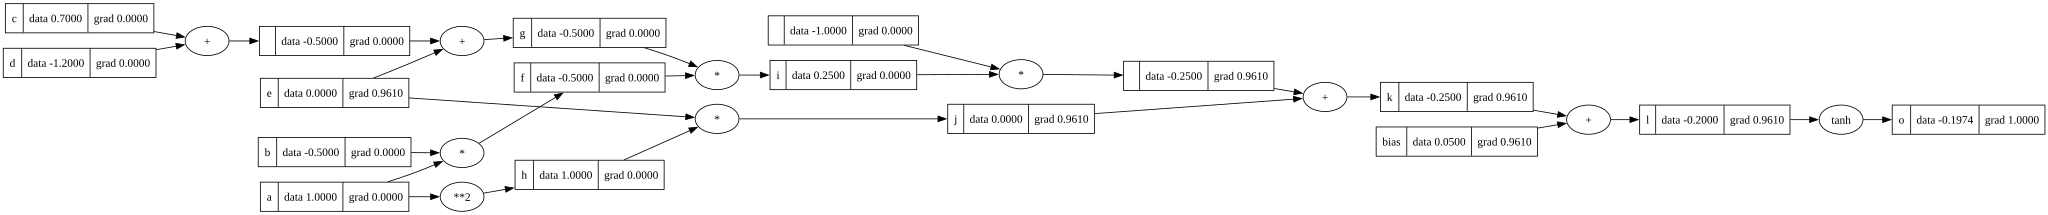

In [ ]:
# remember to initialize the nodes to 0 except loss node, in case the cell is rerun
o.grad = 1.0
l.grad = 0
k.grad = 0
j.grad = 0
i.grad = 0
h.grad = 0
g.grad = 0
f.grad = 0
bias.grad = 0
e.grad = 0
d.grad = 0
c.grad = 0
b.grad = 0
a.grad = 0

o._backward()
l._backward()
k._backward()
j._backward()
i._backward()
h._backward()
g._backward()
f._backward()
bias._backward()
e._backward()
d._backward()
c._backward()
b._backward()
a._backward()
draw_dot(o)

# we see a problem here, manual backprop fails at nodes that have more than 2 functions, i.e. k = j - i = j + (-1) * i
# this is because we did not have a way to manually backprop for -i = -1 * i
# one way to fix this is to decompose our functions into 2 per line, e.g. i_neg = -1*i, k = j + i_neg, or to use a function that automatically
# stores these unassigned values like below

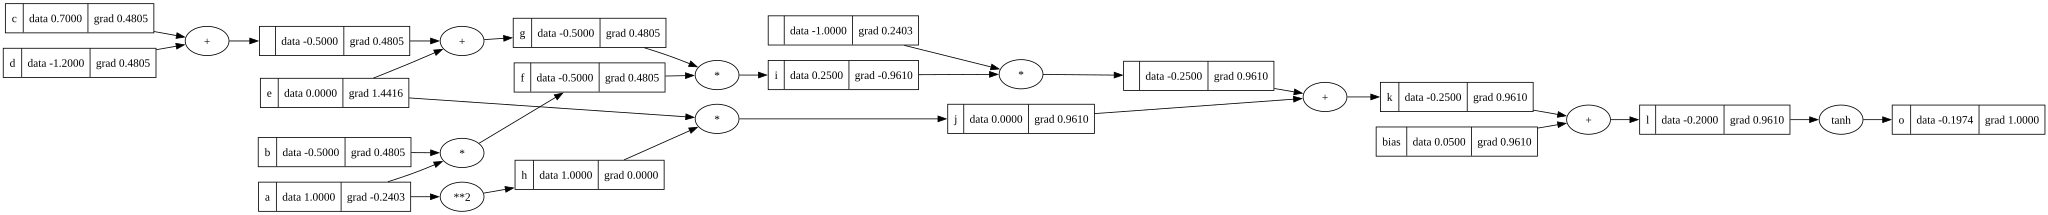

a grad: -0.24026074574152914
b grad: 0.4805214914830583
c grad: 0.4805214914830583
d grad: 0.4805214914830583
e grad: 1.441564474449175
bias grad: 0.9610429829661166
f grad: 0.4805214914830583
g grad: 0.4805214914830583
h grad: 0.0
i grad: -0.9610429829661166
j grad: 0.9610429829661166
k grad: 0.9610429829661166
l grad: 0.9610429829661166
o grad: 1.0


In [237]:
# But using a loop with topological sort circumvents this issue

o.backward()
display(draw_dot(o))

print('a grad:', a.grad)
print('b grad:', b.grad)
print('c grad:', c.grad)
print('d grad:', d.grad)
print('e grad:', e.grad)
print('bias grad:', bias.grad)
print('f grad:', f.grad)
print('g grad:', g.grad)
print('h grad:', h.grad)
print('i grad:', i.grad)
print('j grad:', j.grad)
print('k grad:', k.grad)
print('l grad:', l.grad)
print('o grad:', o.grad)

In [ ]:
# check against pytorch
import torch

a = torch.Tensor([1.0]).double()            ; a.requires_grad = True
b = torch.Tensor([-0.5]).double()           ; b.requires_grad = True
c = torch.Tensor([0.7]).double()            ; c.requires_grad = True
d = torch.Tensor([-1.2]).double()           ; d.requires_grad = True
e = torch.Tensor([0.0]).double()            ; e.requires_grad = True
bias = torch.Tensor([0.05]).double()        ; bias.requires_grad = True

f = a*b; f.label = 'f'                      #; f.requires_grad = True
g = c+d+e; g.label = 'g'                    #; g.requires_grad = True
h = a**2; h.label = 'h'                     #; h.requires_grad = True

i = f*g; i.label = 'i'                      #; i.requires_grad = True
j = h*e; j.label = 'j'                      #; j.requires_grad = True

k = j-i; k.label = 'k'                      #; k.requires_grad = True
l = k + bias; l.label = 'l'                 #; l.requires_grad = True
o = l.tanh(); o.label = 'o'                 #; o.requires_grad = True

o.backward()

print('a grad:', a.grad.item())
print('b grad:', b.grad.item())
print('c grad:', c.grad.item())
print('d grad:', d.grad.item())
print('e grad:', e.grad.item())
print('bias grad:', bias.grad.item())

# we see that the results of rebuilt micrograd using backward() matches pytorch's leaf node 

a grad: -0.2402607716269609
b grad: 0.4805215432539218
c grad: 0.48052148597129685
d grad: 0.48052148597129685
e grad: 1.4415644579138904
bias grad: 0.9610429719425937
